# XGBoost Pipeline — LendingClub

Clean, end-to-end pipeline: load → target → leakage drop → feature engineering → splits (random + OOT) → logistic-regression + XGBoost baselines → Optuna tuning → evaluation → SHAP interpretation.

## 1. Problem Framing

**Goal:** predict whether a LendingClub loan will default, using only information available at the moment of application, so the model could support an accept/reject decision in the real world.

**Why it matters:** lending is asymmetric. A default loses most of the principal, while a good loan earns only a few percent interest. Even a small improvement in ranking risk at origination has a large effect on portfolio losses.

**Target:** binary — `1 = default` (Charged Off / Default), `0 = fully repaid`. In-progress loans are excluded (outcome unknown). 

**Approach:**
- **Logistic regression** as an interpretable baseline, **XGBoost** as the primary model.
- **Feature engineering**: 
- Two evaluation splits: a **random** split (optimistic — same era) and a **time-based / out-of-time** split (trains on older loans, tests on newer ones, mimicking real deployment). Comparing them shows how well the model generalises across time.
- **Hyperparameter tuning with Optuna**: the XGBoost hyperparameters are searched with Optuna, using **StratifiedKFold** cross-validation inside the training set so the default rate is preserved across folds and the test set stays untouched.
- Class imbalance (~20% default): headline metrics are **AUC and PR-AUC**, not accuracy.
- **SHAP interpretation**: explain the tuned model both globally (which features drive risk) and per-loan (why an individual loan scores as it does), which is essential for a lending decision that must be justifiable.


In [141]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [142]:
RANDOM_STATE = 42

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "lendingclub"
LC_LOAN_PATH = DATA_DIR / "lc_loan.csv"
LC_2016_PATH = DATA_DIR / "lc_2016_2017.csv"

sns.set_theme(style="whitegrid")

## 2. Data Understanding

### 2.1 Data Inventory

#### 2.1.1 Files listing and sizes

In [143]:
# Confirm the data folder exists and list contents with file sizes
# (DATA_DIR is defined in the config cell at the top of the notebook)
assert DATA_DIR.exists(), f"Data folder not found at {DATA_DIR.resolve()}"

print(f"{'File':<35} {'Size (MB)':>10}")
print("-" * 47)
for f in sorted(DATA_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"{f.name:<35} {size_mb:>10.1f}")

File                                 Size (MB)
-----------------------------------------------
LCDataDictionary.xlsx                      0.0
lc_2016_2017.csv                         282.7
lc_loan.csv                              441.8
new.html                                   0.0
us-state-codes.csv                         0.0


#### 2.1.2 Inspect 'lc_loan.csv' and 'lc_2016_2017.csv' files

In [144]:
# Load only first 5 rows of lc_loan.csv and lc_2016_2017.csv to confirm structure and column names
lc_loan_preview = pd.read_csv(DATA_DIR / "lc_loan.csv", nrows=5, low_memory=False)
lc_2016_2017_preview = pd.read_csv(DATA_DIR / "lc_2016_2017.csv", nrows=5, low_memory=False)

print(f"lc_loan.csv: first 5 rows")
print(f"  Shape (preview): {lc_loan_preview.shape}")
display(lc_loan_preview)

print(f"\nlc_2016_2017.csv: first 5 rows")
print(f"  Shape (preview): {lc_2016_2017_preview.shape}")
display(lc_2016_2017_preview)

lc_loan.csv: first 5 rows
  Shape (preview): (5, 74)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



lc_2016_2017.csv: first 5 rows
  Shape (preview): (5, 72)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,112435993,NaN,2300,2300,2300,36 months,12.62,77.08,C,C1,...,0,NaN,1,2,2315,55,7100,1,0,2
1,112290210,NaN,16000,16000,16000,60 months,12.62,360.95,C,C1,...,11078,69.0,3,5,1962,94,31900,0,6,1
2,112436985,NaN,6025,6025,6025,36 months,15.05,209.01,C,C4,...,0,NaN,1,2,1950,45,27700,1,5,3
3,112439006,NaN,20400,20400,20400,36 months,9.44,652.91,B,B1,...,53566,95.0,1,2,4240,60,46900,1,1,1
4,112438929,NaN,13000,13000,13000,36 months,11.99,431.73,B,B5,...,8466,72.0,0,1,2996,78,7800,0,0,0


#### - Full shape of each file (rows × columns)

In [145]:
# Load the full files to get exact row counts and shapes.
lc_loan = pd.read_csv(DATA_DIR / "lc_loan.csv", low_memory=False)
print(f"lc_loan.csv:        {lc_loan.shape[0]:>10,} rows x {lc_loan.shape[1]:>3} columns")

lc_2016_2017 = pd.read_csv(DATA_DIR / "lc_2016_2017.csv", low_memory=False)
print(f"lc_2016_2017.csv:   {lc_2016_2017.shape[0]:>10,} rows x {lc_2016_2017.shape[1]:>3} columns")

print(f"\nCombined:           {lc_loan.shape[0] + lc_2016_2017.shape[0]:>10,} rows total")

lc_loan.csv:           887,379 rows x  74 columns
lc_2016_2017.csv:      759,338 rows x  72 columns

Combined:            1,646,717 rows total


### - Schema comparison: do the two CSVs share columns?

In [146]:
# Get column sets from each file
cols_main = set(lc_loan.columns)
cols_2016_2017 = set(lc_2016_2017.columns)

# Identify differences
only_in_main = cols_main - cols_2016_2017
only_in_2016_2017 = cols_2016_2017 - cols_main
in_both = cols_main & cols_2016_2017

print(f"Columns in lc_loan.csv only:       {len(only_in_main)}")
print(f"Columns in lc_2016_2017.csv only:  {len(only_in_2016_2017)}")
print(f"Columns in both files:              {len(in_both)}")

if only_in_main:
    print(f"\nIn lc_loan.csv but NOT in lc_2016_2017.csv:")
    for col in sorted(only_in_main):
        print(f"  - {col}")

if only_in_2016_2017:
    print(f"\nIn lc_2016_2017.csv but NOT in lc_loan.csv:")
    for col in sorted(only_in_2016_2017):
        print(f"  - {col}")

Columns in lc_loan.csv only:       2
Columns in lc_2016_2017.csv only:  0
Columns in both files:              72

In lc_loan.csv but NOT in lc_2016_2017.csv:
  - open_il_6m
  - url


#### - Date range of each file (overlap check)

In [147]:
# Parse issue_d to datetime for both files
lc_loan['issue_d'] = pd.to_datetime(lc_loan['issue_d'], format='%b-%Y', errors='coerce')
lc_2016_2017['issue_d'] = pd.to_datetime(lc_2016_2017['issue_d'], format='%b-%Y', errors='coerce')

print("Date ranges per file:")
print(f"  lc_loan.csv:        {lc_loan['issue_d'].min()} to {lc_loan['issue_d'].max()}")
print(f"  lc_2016_2017.csv:   {lc_2016_2017['issue_d'].min()} to {lc_2016_2017['issue_d'].max()}")

# Check for overlap
overlap_start = max(lc_loan['issue_d'].min(), lc_2016_2017['issue_d'].min())
overlap_end = min(lc_loan['issue_d'].max(), lc_2016_2017['issue_d'].max())

if overlap_start <= overlap_end:
    overlap_rows_main = ((lc_loan['issue_d'] >= overlap_start) & (lc_loan['issue_d'] <= overlap_end)).sum()
    overlap_rows_2016_2017 = ((lc_2016_2017['issue_d'] >= overlap_start) & (lc_2016_2017['issue_d'] <= overlap_end)).sum()
    print(f"\nWARNING: Date ranges overlap from {overlap_start} to {overlap_end}")
    print(f"  Overlapping rows in lc_loan.csv:       {overlap_rows_main:,}")
    print(f"  Overlapping rows in lc_2016_2017.csv:  {overlap_rows_2016_2017:,}")
else:
    print(f"\nFiles cover non-overlapping date ranges - safe to concatenate.")

# Distribution of loans by year to see the temporal shape
print("\nLoan counts by issue year:")
combined_temp = pd.concat([
    lc_loan[['issue_d']].assign(source='lc_loan'),
    lc_2016_2017[['issue_d']].assign(source='lc_2016_2017')
])
combined_temp['year'] = combined_temp['issue_d'].dt.year
print(combined_temp.groupby(['year', 'source']).size().unstack(fill_value=0))

Date ranges per file:
  lc_loan.csv:        2007-06-01 00:00:00 to 2015-12-01 00:00:00
  lc_2016_2017.csv:   2016-01-01 00:00:00 to 2017-09-01 00:00:00

Files cover non-overlapping date ranges - safe to concatenate.

Loan counts by issue year:
source  lc_2016_2017  lc_loan
year                         
2007               0      603
2008               0     2393
2009               0     5281
2010               0    12537
2011               0    21721
2012               0    53367
2013               0   134755
2014               0   235628
2015               0   421094
2016          434407        0
2017          324931        0


#### - Dtype summary

In [148]:
print("Data type distribution in lc_loan.csv:")
print(lc_loan.dtypes.value_counts())
print()
print("Data type distribution in lc_2016_2017.csv:")
print(lc_2016_2017.dtypes.value_counts())

Data type distribution in lc_loan.csv:
float64           49
str               22
int64              2
datetime64[us]     1
Name: count, dtype: int64

Data type distribution in lc_2016_2017.csv:
float64           40
str               21
int64             10
datetime64[us]     1
Name: count, dtype: int64


#### 2.1.3 Inspect us-state-codes.csv and new.html

#### - us-state-codes.csv

In [149]:
# us-state-codes.csv: Preview first 10 rows and column names
us_states = pd.read_csv(DATA_DIR / "us-state-codes.csv")
print(f"us-state-codes.csv shape: {us_states.shape}")
print(us_states.head(10))
print(f"\nColumn names: {list(us_states.columns)}")


us-state-codes.csv shape: (57, 2)
  state_code        state
0      US-AL      Alabama
1      US-AK       Alaska
2      US-AZ      Arizona
3      US-AR     Arkansas
4      US-CA   California
5      US-CO     Colorado
6      US-CT  Connecticut
7      US-DE     Delaware
8      US-FL      Florida
9      US-GA      Georgia

Column names: ['state_code', 'state']


- us-state-codes.csv contains a simple 2-column mapping of state abbreviations to full names. This will be used later for state-level analysis or display purposes, but it's not required for modelling because addr_state in the main data is already the abbreviation that is needed.

#### - new.html

In [150]:
# new.html: peek at content to determine its role
with open(DATA_DIR / "new.html", "r", encoding="utf-8") as f:
    html_preview = f.read()

print(f"new.html size: {len(html_preview):,} characters")
print(f"\nFirst 500 characters:")
print(html_preview[:500])

new.html size: 5,329 characters

First 500 characters:
 <!-- GeoChart generated in R 3.4.2 by googleVis 0.6.2 package -->
 <!-- Thu Jun 28 07:27:57 2018 -->
 
 
 <!-- jsHeader -->
 <script type="text/javascript">
  
 // jsData 
 function gvisDataGeoChartID12f3f099d () {
 var data = new google.visualization.DataTable();
 var datajson =
 [
  [
 "US-AK",
 "Alaska- Defaulters:151",
 0.22
 ],
 [
 "US-AL",
 "Alabama- Defaulters:993",
 1.47
 ],
 [
 "US-AR",
 "Arkansas- Defaulters:507",
 0.75
 ],
 [
 "US-AZ",
 "Arizona- Defaulters:1581",
 2.34
 ],
 [
 "US-C


#### 2.1.4 Combine the two loan files: lc_loan + lc_2016_2017

In [151]:
# Combine the two loan files, keeping only shared columns
shared_columns = sorted(in_both)
df = pd.concat([
    lc_loan[shared_columns],
    lc_2016_2017[shared_columns]
], ignore_index=True)

print(f"Combined dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['issue_d'].min()} to {df['issue_d'].max()}")

Combined dataset shape: 1,646,717 rows x 72 columns
Date range: 2007-06-01 00:00:00 to 2017-09-01 00:00:00


### Modelling dataset decision

Based on the inventory above, the modelling dataset is constructed as follows:

- **Source files:** lc_loan.csv (2007-2015) + lc_2016_2017.csv (2016-2017)
- **Columns kept:** The 72 columns shared between both files. The 2 columns unique to lc_loan.csv (open_il_6m, url) are dropped for a unified schema.
- **Row handling:** Files are concatenated since their date ranges do not overlap.
- **Total dataset:** 1.65 million loans spanning 2007-2017 (narrowed to 424,890 once in-progress loans are excluded in §2.2.1).


**Implications:**
- The clean 2015/2016 boundary between files is convenient since it can serve as the time-based split 
- `us-state-codes.csv` will not be used for modelling; only for display in EDA if relevant
- A column data dictionary (`LCDataDictionary.xlsx`) is kept in `data/lendingclub/` for reference when interpreting fields.

### 2.1.5 String harmonisation

- strip whitespace 
across all object columns to ensure consistent values.

In [152]:
object_cols = df.select_dtypes(include='str').columns.tolist()

# Audit: which columns have whitespace inconsistencies?
inconsistent_cols = []
for col in object_cols:
    before = df[col].nunique(dropna=True)
    after = df[col].str.strip().nunique(dropna=True)
    if before != after:
        inconsistent_cols.append(col)
        print(f"  {col}: {before} → {after} unique values after strip "
              f"({before - after} whitespace duplicates)")

# Apply strip to all object columns
for col in object_cols:
    df[col] = df[col].str.strip()

if inconsistent_cols:
    print(f"\nHarmonised {len(inconsistent_cols)} columns affected by whitespace inconsistencies.")
else:
    print("No whitespace inconsistencies detected.")

  desc: 124484 → 124468 unique values after strip (16 whitespace duplicates)
  emp_title: 424073 → 412474 unique values after strip (11599 whitespace duplicates)
  term: 4 → 2 unique values after strip (2 whitespace duplicates)
  title: 63143 → 61444 unique values after strip (1699 whitespace duplicates)

Harmonised 4 columns affected by whitespace inconsistencies.


### 2.2 Exploratory Data Analysis

- How does default behaviour vary across loan attributes, borrower attributes, and time?

#### 2.2.1 Target variable
- The `loan_status` column 
contains the outcome of each loan. We need to decide which values count as 
"default" (bad, target=1) and which count as fully repaid (good, target=0), 
and exclude loans whose outcome is not yet known.

In [153]:
# Raw distribution of loan_status values
status_counts = df["loan_status"].value_counts(dropna=False)
status_pct = df["loan_status"].value_counts(dropna=False, normalize=True).mul(100).round(2)
pd.DataFrame({"count": status_counts, "pct": status_pct})

,count,pct
loan_status,,
Current,1167302,70.89
Fully Paid,338441,20.55
Charged Off,82445,5.01
Late (31-120 days),26945,1.64
In Grace Period,12887,0.78
Issued,8460,0.51
Late (16-30 days),6233,0.38
Does not meet the credit policy. Status:Fully Paid,1988,0.12
Default,1255,0.08


The credit risk industry convention: **1 = default (bad)**, 
**0 = fully repaid (good)**.

- **Bad (1):** Charged Off, Default, Does not meet credit policy (Charged Off)
- **Good (0):** Fully Paid, Does not meet credit policy (Fully Paid)
- **Excluded:** Current, Issued, In Grace Period, Late (16-30), Late (31-120) are 
  outcomes not yet known

Therefore, in-progress loans are excluded because labelling them as "good" would teach the model that risky loans are safe. 

In [154]:
# Define the bad/good mapping
bad_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
]
good_statuses = [
    'Fully Paid',
    'Does not meet the credit policy. Status:Fully Paid',
]
keep_statuses = bad_statuses + good_statuses

# Filter to loans with definitive outcomes
rows_before = len(df)
df = df[df['loan_status'].isin(keep_statuses)].copy()
print(f"Rows before filtering: {rows_before:,}")
print(f"Rows after filtering:  {len(df):,} ({len(df)/rows_before:.1%} kept)")

# Create binary target
df['target'] = df['loan_status'].isin(bad_statuses).astype(int)

# Class imbalance check
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nDefault rate: {df['target'].mean():.2%}")

Rows before filtering: 1,646,717
Rows after filtering:  424,890 (25.8% kept)

Target distribution:
target
0    340429
1     84461
Name: count, dtype: int64

Default rate: 19.88%


The default rate of 19.88% confirms class imbalance, which has two implications:

1. `StratifiedKFold` is used for cross-validation to preserve the default rate across folds
2. Accuracy alone is a misleading metric. More focus on AUC, precision, recall, F1, and Gini alongside it

#### 2.2.2 Default rate over time

In [155]:
# Extract year from issue_d (already parsed to datetime in inventory step)
df['issue_year'] = df['issue_d'].dt.year

# Default rate by year, with counts
default_by_year = df.groupby('issue_year')['target'].agg(['count', 'mean']).reset_index()
default_by_year.columns = ['issue_year', 'loan_count', 'default_rate']
default_by_year

,issue_year,loan_count,default_rate
0,2007,603,0.262023
1,2008,2393,0.207271
2,2009,5281,0.136906
3,2010,12523,0.140062
4,2011,19683,0.163237
5,2012,49591,0.163578
6,2013,71414,0.210295
7,2014,69307,0.210570
8,2015,26144,0.120869
9,2016,137336,0.248981


**What the data shows:**

- **Loan volume grew massively** — completed-loan counts rise from 603 in 2007 to 137k in 2016 (of ~434k issued that year; the rest are still ongoing and were excluded as in-progress).
- **2015 and 2017 default rates look too low** (12% and 10%). This isn't a real improvement because many recent loans hadn't finished yet when the data was collected, so we're only seeing the ones that ended early (mostly the good ones).
- **2016 jumps to 25%**, much higher than nearby years. 
- **The most reliable years are 2010-2014** (14-21% default rate).

**What this means for modelling:** A time-based split makes sense, but recent test years will look easier than they really are.

#### 2.2.3 Default rate by loan attributes

#### By grade

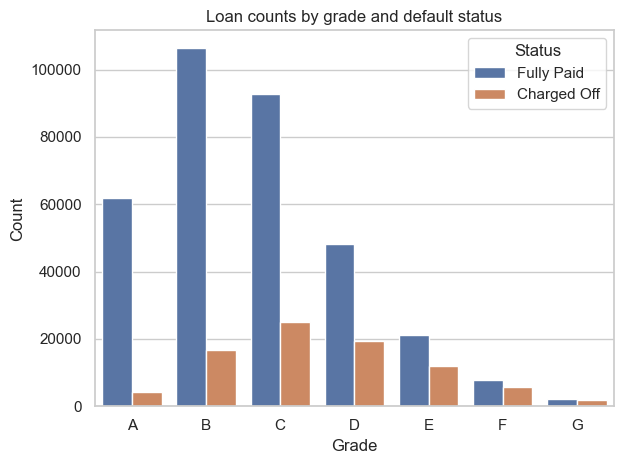

In [156]:
# Count of loans by grade and status
sns.countplot(
    data=df,
    x='grade',
    hue='target',
    order=sorted(df['grade'].unique()),
    hue_order=[0, 1]
)

plt.title('Loan counts by grade and default status')
plt.xlabel('Grade')
plt.ylabel('Count')

# Rename legend labels from 0/1 to readable text
plt.legend(title='Status', labels=['Fully Paid', 'Charged Off'])

plt.tight_layout()
plt.show()

- Loans concentrate in grades A–C; F and G are rare (~5% of loans combined). The different category sizes make it hard to compare risk directly from counts alone. Grade G might look like it has fewer defaults than B in absolute terms, despite being a much riskier population. To compare this, default rate will be used.

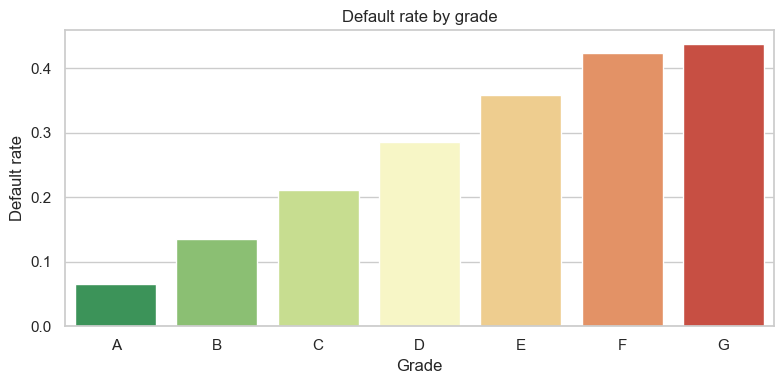

In [157]:
# Default rate by grade
default_rate = df.groupby('grade')['target'].mean().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=default_rate.index, y=default_rate.values, hue=default_rate.index, palette='RdYlGn_r', legend=False)
plt.title('Default rate by grade')
plt.ylabel('Default rate')
plt.xlabel('Grade')
plt.tight_layout()
plt.show()

**Key observations**
- Grade is a strong predictor. Default rate rises monotonically from A (~6%) to G (~43%), a 7× spread with no reversals. 

- The model will be weaker at the risky end Grades F and G have very few loans (small bars in chart 1) despite having the highest default rates. The model will see relatively few examples of the riskiest borrowers, which limits how well it can discriminate among them. So, lower predictive accuracy in F/G should be expected, and flag this as a known limitation when reporting test results.

#### By sub-grade

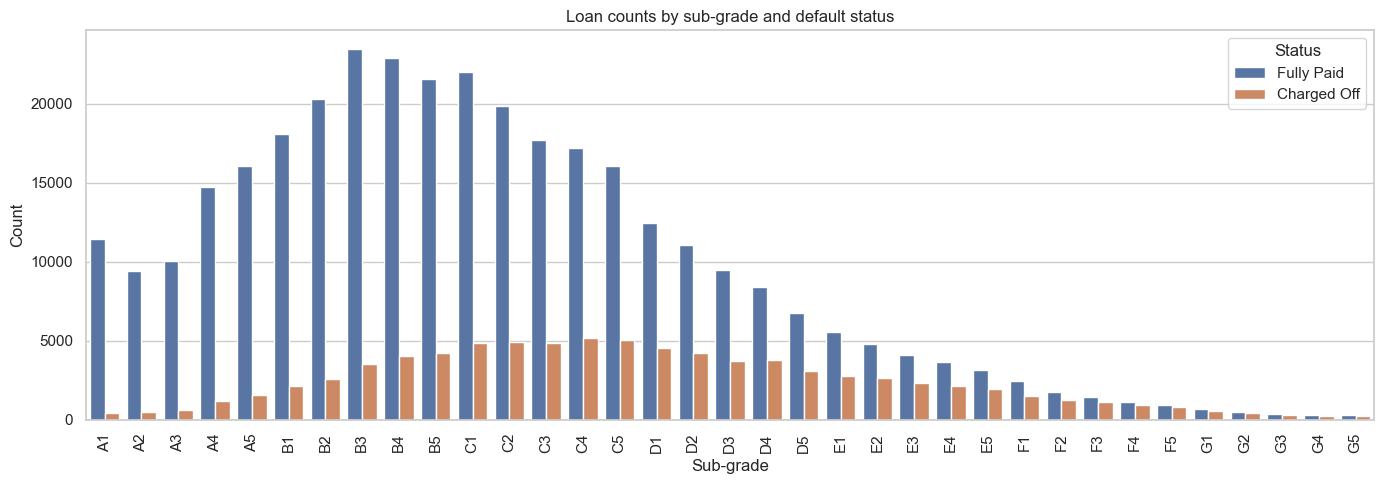

In [158]:
# Loan counts by sub-grade and default status
plt.figure(figsize=(14, 5))
sns.countplot(
    data=df,
    x='sub_grade',
    hue='target',
    order=sorted(df['sub_grade'].unique()),
    hue_order=[0, 1]
)

plt.title('Loan counts by sub-grade and default status')
plt.xlabel('Sub-grade')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='Status', labels=['Fully Paid', 'Charged Off'])
plt.tight_layout()
plt.show()

 - Over 90% of loans sit in A–C, and F and G combined are barely visible on the chart. This matters for modelling: sub-grades at the riskiest end will be learned from a few hundred examples each, so the model's predictions there will be unreliable. To compare default risk fairly, default rate will be used.

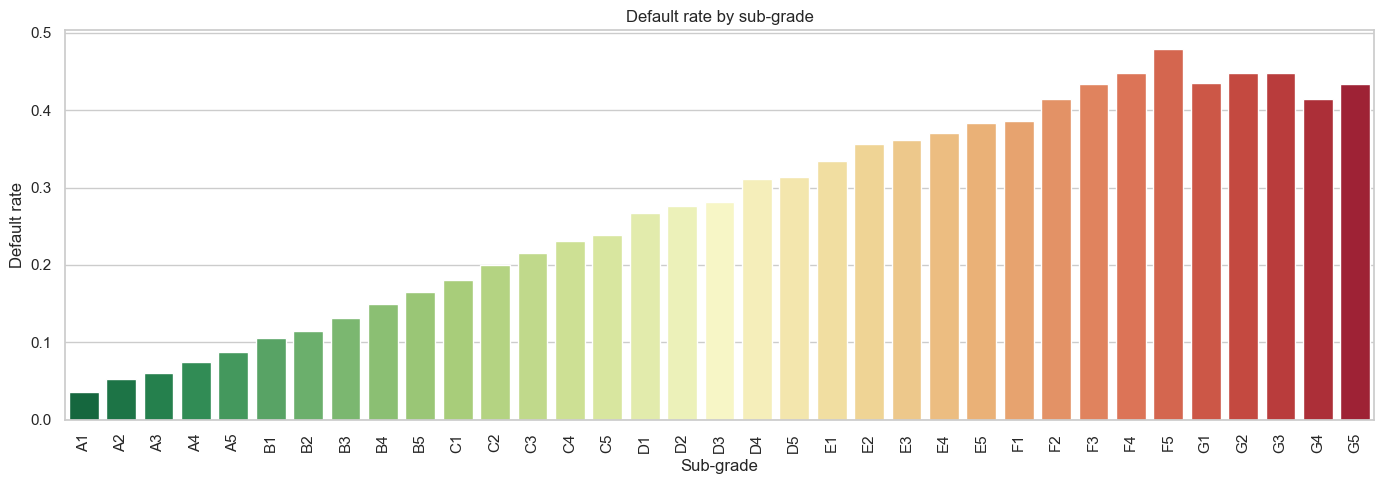

In [159]:
# Default rate by sub-grade
subgrade_default = df.groupby('sub_grade')['target'].mean().sort_index()

plt.figure(figsize=(14, 5))
sns.barplot(
    x=subgrade_default.index,
    y=subgrade_default.values,
    hue=subgrade_default.index,
    palette='RdYlGn_r',
    legend=False
)

plt.title('Default rate by sub-grade')
plt.xlabel('Sub-grade')
plt.ylabel('Default rate')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Key observations**
- **Sub-grade is more informative than grade.** Within grade A alone, default rate doubles from A1 (~4%) to A5 (~9%), so meaningful resolution that gets lost if only grade is used for feeding the model. The same pattern holds across B, C, and D. So, `sub_grade` is more useful when feeding the model.

- **The risky tail is unstable.** F5 is the highest default rate at ~48%, but G1 drops back to ~43% and G4 to ~41%. The ordering breaks down because these sub-grades have few loans (a few hundred each). The model will struggle to discriminate within F and G, so lower predictive accuracy should be expected for borrowers at the risky end, and flag this as a known limitation when reporting results.

#### By loan purpose

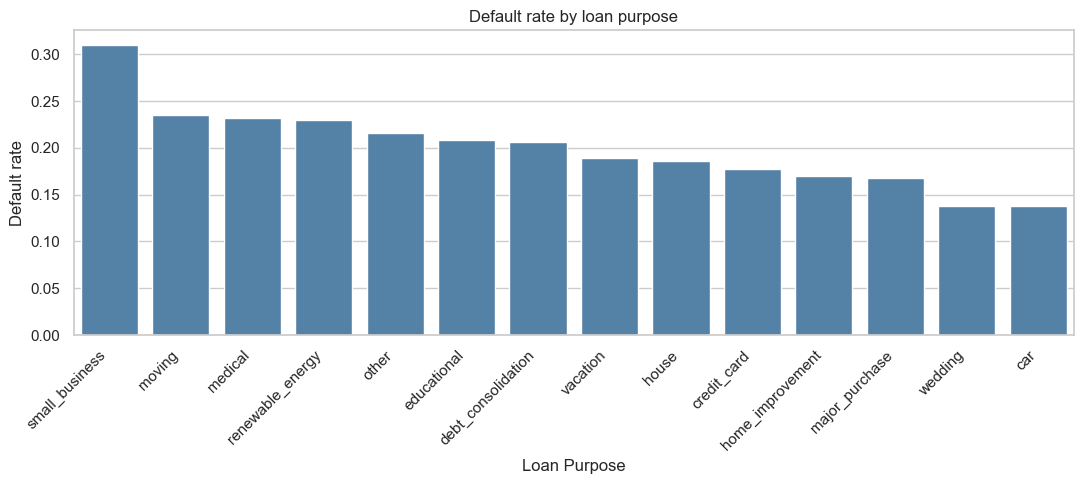

In [160]:
# Does default rate vary with purpose of the loan?
# Default rate by loan purpose, sorted high -> low
purpose_stats = (
    df.groupby('purpose')['target']
      .agg(default_rate='mean', loan_count='count')
      .sort_values('default_rate', ascending=False)
)

plt.figure(figsize=(11, 5))
sns.barplot(x=purpose_stats.index, y=purpose_stats['default_rate'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Default rate by loan purpose')
plt.ylabel('Default rate')
plt.xlabel('Loan Purpose')
plt.tight_layout()
plt.show()

**Key Observations:**
- **Small business loans** show the highest default rate (~31%) when the underlying business fails, the borrower loses the income to repay the loan
- **Moving, medical, and renewable energy** sit in the 23-24% range, which is typically unplanned or financially stretched situations
- These loan purpose categories could be useful predictors of whether or not a borrower will default on his/her loan.

#### By term

- LendingClub offers two loan terms: 36 months and 60 months. Borrowers self-select into one or the other based on monthly payment affordability. 

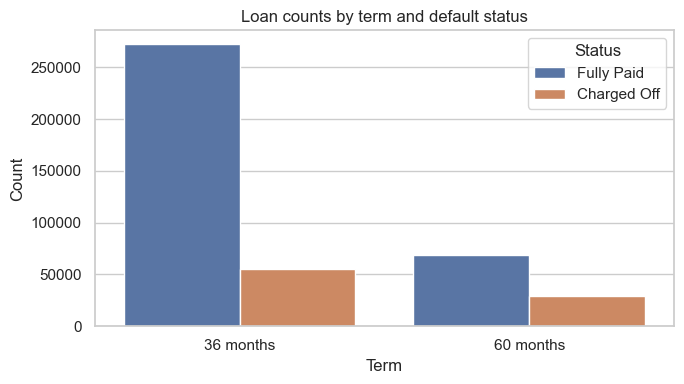

In [161]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x='term',
    hue='target',
    hue_order=[0, 1]
)

plt.title('Loan counts by term and default status')
plt.xlabel('Term')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Fully Paid', 'Charged Off'])
plt.tight_layout()
plt.show()

- 36-month loans dominate (~80% of loans), but defaults appear in both. 

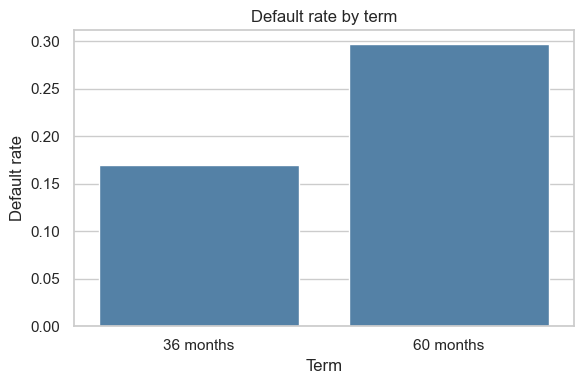

In [162]:
term_default = df.groupby('term')['target'].mean()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=term_default.index,
    y=term_default.values,
    color = 'steelblue'
)

plt.title('Default rate by term')
plt.xlabel('Term')
plt.ylabel('Default rate')
plt.tight_layout()
plt.show()

**Key Observations:**
- 60-month loans are a minority (~20% of loans) but still number in the tens of thousands, so their higher default rate is a reliable signal, not a small-sample problem.

- Riskier borrowers self-select into longer terms to lower their monthly payment, and longer exposure gives more opportunities to default. Term is a strong feature.

- Term likely overlaps with grade and interest rate. 60-month loans are typically priced higher (worse grades, higher rates), so some of term's predictive power may already be captured by features that are already explored.


#### 2.2.4 Default rate by borrower attributes

#### By Debt-to-income ratio
- measures how much of a borrower's monthly income is already committed to existing debt payments, excluding mortgage. 

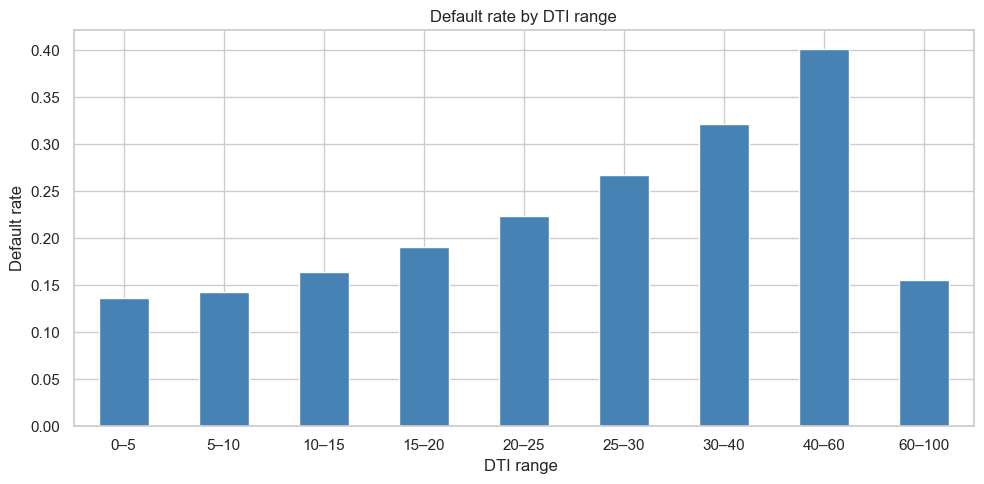

In [163]:
# Create DTI bins 
dti_bins = [0, 5, 10, 15, 20, 25, 30, 40, 60, 100]
dti_labels = [f'{dti_bins[i]}–{dti_bins[i+1]}' for i in range(len(dti_bins) - 1)]

# Remove invalid negative DTI values
df_dti = df[df['dti'] >= 0].copy()
df_dti['dti_bin'] = pd.cut(df_dti['dti'], bins=dti_bins, labels=dti_labels)

dti_default = df_dti.groupby('dti_bin')['target'].mean()

dti_default.plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Default rate by DTI range')
plt.xlabel('DTI range ')
plt.ylabel('Default rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [164]:
# Investigate the 60-100% DTI bin - how many loans are there?
dti_counts = df_dti.groupby('dti_bin').size()
print(dti_counts)

dti_bin
0–5       25259
5–10      61040
10–15     90639
15–20     93226
20–25     76024
25–30     47234
30–40     29594
40–60      1277
60–100      109
dtype: int64


**Key points:**

1. **DTI is a strong predictor up to 40%.** The relationship steepens above DTI 25%, suggesting a financial stress threshold worth flagging as a feature engineering candidate (e.g. a "high DTI" indicator).

2. **The extreme DTI bins are unreliable due to small samples.** The 40-60% bin contains 1,277 loans and the 60-100% bin only 109 loans (0.03%), which are too few to trust the estimated default rates. The apparent drop in the 60-100% bin is almost certainly noise, not a real pattern. LendingClub likely auto-rejects most applicants above DTI 40%, leaving only a tiny filtered sample in the data.

3. **The non-linear shape favours tree-based models.** Default rate is flat at the low end and steepens in the middle. XGBoost will capture this. For logistic regression, binning DTI or adding a polynomial term may help since the relationship isn't linear.

#### By annual income

In [165]:
# Income distribution - check skewness first for deciding the bins
print(f"Annual income skewness: {df['annual_inc'].skew():.2f}")
print(f"Annual income kurtosis: {df['annual_inc'].kurtosis():.2f}")
print(f"99th percentile: ${df['annual_inc'].quantile(0.99):,.0f}")
print(f"Max value:       ${df['annual_inc'].max():,.0f}")

Annual income skewness: 47.01
Annual income kurtosis: 4913.19
99th percentile: $250,000
Max value:       $9,550,000


- Annual income is strongly right-skewed, with a small number of borrowers earning over $500k while most earn under $80k. Instead of capping these values,  an open-ended 160k+ group is kept since high-income borrowers are a valid segment, not true outliers.

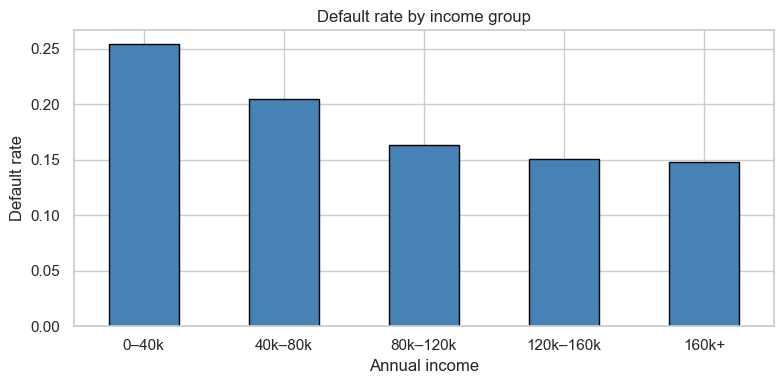

In [166]:
# Bin income
income_bins = [0, 40000, 80000, 120000, 160000, np.inf]
income_labels = ['0–40k', '40k–80k', '80k–120k', '120k–160k', '160k+']

df['income_bin'] = pd.cut(df['annual_inc'], bins=income_bins, labels=income_labels)
income_default = df.groupby('income_bin')['target'].mean()

income_default.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(8, 4))
plt.title('Default rate by income group')
plt.xlabel('Annual income')
plt.ylabel('Default rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Key observations:**
- **Higher income is generally linked to lower default risk, although the effect becomes smaller at higher income levels.** Borrowers earning under $40k have a default rate of around 25%, while those earning above $80k are closer to 15–16%. The biggest difference is really at the lower-income end. Once income gets beyond around $80k, the improvement in risk starts to level off. In practice, someone earning $200k is not dramatically safer than someone earning $100k.
- **Income also overlaps with other factors that are already looked at.** Lower-income borrowers often have higher DTI ratios and poorer loan grades, so part of the effect of income may already be reflected through those variables

#### 2.2.5 Missingness analysis

In [167]:
# Missingness per column, sorted
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})

# Show only columns with at least one missing value
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
verification_status_joint,421324,99.16
annual_inc_joint,421324,99.16
dti_joint,421324,99.16
next_pymnt_d,420886,99.06
mths_since_last_record,357644,84.17
desc,334017,78.61
mths_since_last_major_derog,328325,77.27
il_util,278036,65.44
mths_since_rcnt_il,260568,61.33
all_util,256830,60.45


In [168]:
# Check whether missingness itself predicts default
cols_to_check = [
    'emp_length',
    'mths_since_last_delinq',
    'mths_since_last_record',
    'mths_since_last_major_derog',
    'tot_cur_bal',
]

print("Default rate by missingness:\n")
for col in cols_to_check:
    if col in df.columns:
        missing_default = df[df[col].isnull()]['target'].mean()
        present_default = df[df[col].notnull()]['target'].mean()
        diff = missing_default - present_default
        print(f"{col}:")
        print(f"  Default rate when missing:  {missing_default:.2%}")
        print(f"  Default rate when present:  {present_default:.2%}")
        print(f"  Difference:                 {diff:+.2%}")
        print()

Default rate by missingness:

emp_length:
  Default rate when missing:  28.47%
  Default rate when present:  19.44%
  Difference:                 +9.04%

mths_since_last_delinq:
  Default rate when missing:  19.49%
  Default rate when present:  20.30%
  Difference:                 -0.81%

mths_since_last_record:
  Default rate when missing:  19.63%
  Default rate when present:  21.20%
  Difference:                 -1.57%

mths_since_last_major_derog:
  Default rate when missing:  19.46%
  Default rate when present:  21.29%
  Difference:                 -1.82%

tot_cur_bal:
  Default rate when missing:  16.24%
  Default rate when present:  20.55%
  Difference:                 -4.31%



#### Column categorisation

Before the treatment plan, every column is assigned to an explicit DROP or KEEP bucket. This is the auditable record of the leakage audit: post-origination fields, identifiers, >99%-missing joint fields, the newer ~60%-missing bureau metrics, high-cardinality text, and near-constant columns are dropped; the rest are kept (with a documented missing-value treatment).

In [169]:
# Column categorisation for the leakage audit + cleaning plan (§3.1).
# Every column is explicitly assigned to a DROP or KEEP bucket so the
# decision is auditable. Lists hold only columns present in the combined
# 72-column schema, plus the EDA helper columns issue_year / income_bin.

# --- DROP buckets ---
drop_post_origination = [   # populated only AFTER the loan outcome -> target leakage
    "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",
]
drop_identifiers = [        # unique IDs - no predictive value
    "id", "member_id",
]
drop_joint = [              # joint-application fields, >99% missing
    "annual_inc_joint", "dti_joint", "verification_status_joint",
]
drop_newer_bureau = [       # bureau metrics added in later LC releases, ~60% missing
    "open_acc_6m", "open_il_12m", "open_il_24m", "mths_since_rcnt_il",
    "total_bal_il", "il_util", "open_rv_12m", "open_rv_24m",
    "max_bal_bc", "all_util", "inq_fi", "total_cu_tl", "inq_last_12m",
]
drop_text = [               # high-cardinality / free-text - need NLP, out of scope
    "emp_title", "desc", "title", "zip_code",
]
drop_constant = [           # near-constant, no variance to learn from
    "policy_code", "pymnt_plan",
]
drop_other = [              # target source, split key, investor-side dup, EDA helpers
    "loan_status", "funded_amnt_inv", "income_bin",
]

# --- KEEP buckets (missing-value treatment applied in §3.1.2) ---
keep_sentinel_fill = [      # "months since <event>": missing = event never happened
    "mths_since_last_delinq", "mths_since_last_record", "mths_since_last_major_derog",
]
keep_median_impute = [      # missing reflects loan timing, not borrower behaviour
    "tot_cur_bal", "total_rev_hi_lim", "tot_coll_amt",
]
keep_signal_missing = [     # missingness itself predicts default (+9pp) -> treat as 'unknown'
    "emp_length",
]

# Split keys: kept in df for the Section 3.4 time-based split, but NOT model
# features (issue_d is a datetime; issue_year would leak the era into the model).
split_keys = ['issue_d', 'issue_year']

# usable_features = everything not dropped, not a split key, and not the target.
_all_drops = (drop_post_origination + drop_identifiers + drop_joint
              + drop_newer_bureau + drop_text + drop_constant + drop_other)
usable_features = [c for c in df.columns
                   if c not in _all_drops and c not in split_keys and c != 'target']

print(f"Columns flagged to DROP : {len(_all_drops)}")
print(f"Usable features (KEEP)  : {len(usable_features)}")


Columns flagged to DROP : 40
Usable features (KEEP)  : 32


In [170]:
# Treatment plan based on the audit
# This serves as the reference for Section 3.1 (Data Cleaning)

treatment_plan = pd.DataFrame([
    {'Action': 'DROP', 'Reason': 'Post-origination (leakage)',         'Count': len(drop_post_origination)},
    {'Action': 'DROP', 'Reason': 'Identifiers',                         'Count': len(drop_identifiers)},
    {'Action': 'DROP', 'Reason': 'Joint fields (>99% missing)',         'Count': len(drop_joint)},
    {'Action': 'DROP', 'Reason': 'Newer bureau metrics (~60% missing)', 'Count': len(drop_newer_bureau)},
    {'Action': 'DROP', 'Reason': 'High-cardinality text',               'Count': len(drop_text)},
    {'Action': 'DROP', 'Reason': 'Near-constant',                       'Count': len(drop_constant)},
    {'Action': 'DROP', 'Reason': 'Helpers and used elsewhere',          'Count': len(drop_other)},
    {'Action': 'KEEP', 'Reason': 'Sentinel fill with 999',              'Count': len(keep_sentinel_fill)},
    {'Action': 'KEEP', 'Reason': 'Median impute',                       'Count': len(keep_median_impute)},
    {'Action': 'KEEP', 'Reason': 'Treat missing as signal',             'Count': len(keep_signal_missing)},
    {'Action': 'KEEP', 'Reason': 'Use as-is (low missingness)',         
     'Count': len(usable_features) - len(keep_sentinel_fill) - len(keep_median_impute) - len(keep_signal_missing)},
])

print(f"Total usable features for modelling: {len(usable_features)}")
treatment_plan

Total usable features for modelling: 32


,Action,Reason,Count
0,DROP,Post-origination (leakage),13
1,DROP,Identifiers,2
2,DROP,Joint fields (>99% missing),3
3,DROP,Newer bureau metrics (~60% missing),13
4,DROP,High-cardinality text,4
5,DROP,Near-constant,2
6,DROP,Helpers and used elsewhere,3
7,KEEP,Sentinel fill with 999,3
8,KEEP,Median impute,3
9,KEEP,Treat missing as signal,1


#### 2.2.6 Distributions of kept numeric features

In [171]:
# Identify usable numeric features:
usable_numeric = [c for c in usable_features if df[c].dtype in ['int64', 'int32', 'float64', 'float32']]
print(f"Usable numeric features: {len(usable_numeric)}")

Usable numeric features: 21


In [172]:
# Some numeric features aren't informative as histograms
exclude_from_viz = [
    'acc_now_delinq',
    'collections_12_mths_ex_med',
    'mths_since_last_delinq',
    'mths_since_last_major_derog',
    'mths_since_last_record',
]

numeric_features = [c for c in usable_numeric if c not in exclude_from_viz]
print(f"Visualising {len(numeric_features)} features (excluding mostly-zero and high-missing)")

Visualising 16 features (excluding mostly-zero and high-missing)


**NOTE:** Some features have extreme outliers or heavy right-skew that make raw histograms unreadable. Two types of transformations are applied:

**1. LOG SCALE:** This is for heavily right-skewed to compress the long tail and reveals the actual distribution shape. Features that apply log scale are `annual_inc`, 
`revol_bal`, `tot_cur_bal`, `total_rev_hi_lim`

**2. CLIP:** This is for features where extreme values are likely data errors rather than legitimate outliers. DTI above 100% is implausible for a healthy applicant, so those rows are excluded from the visualisation


Visualising 12 features (excluding zero-inflated, high-missing, and time-key columns)


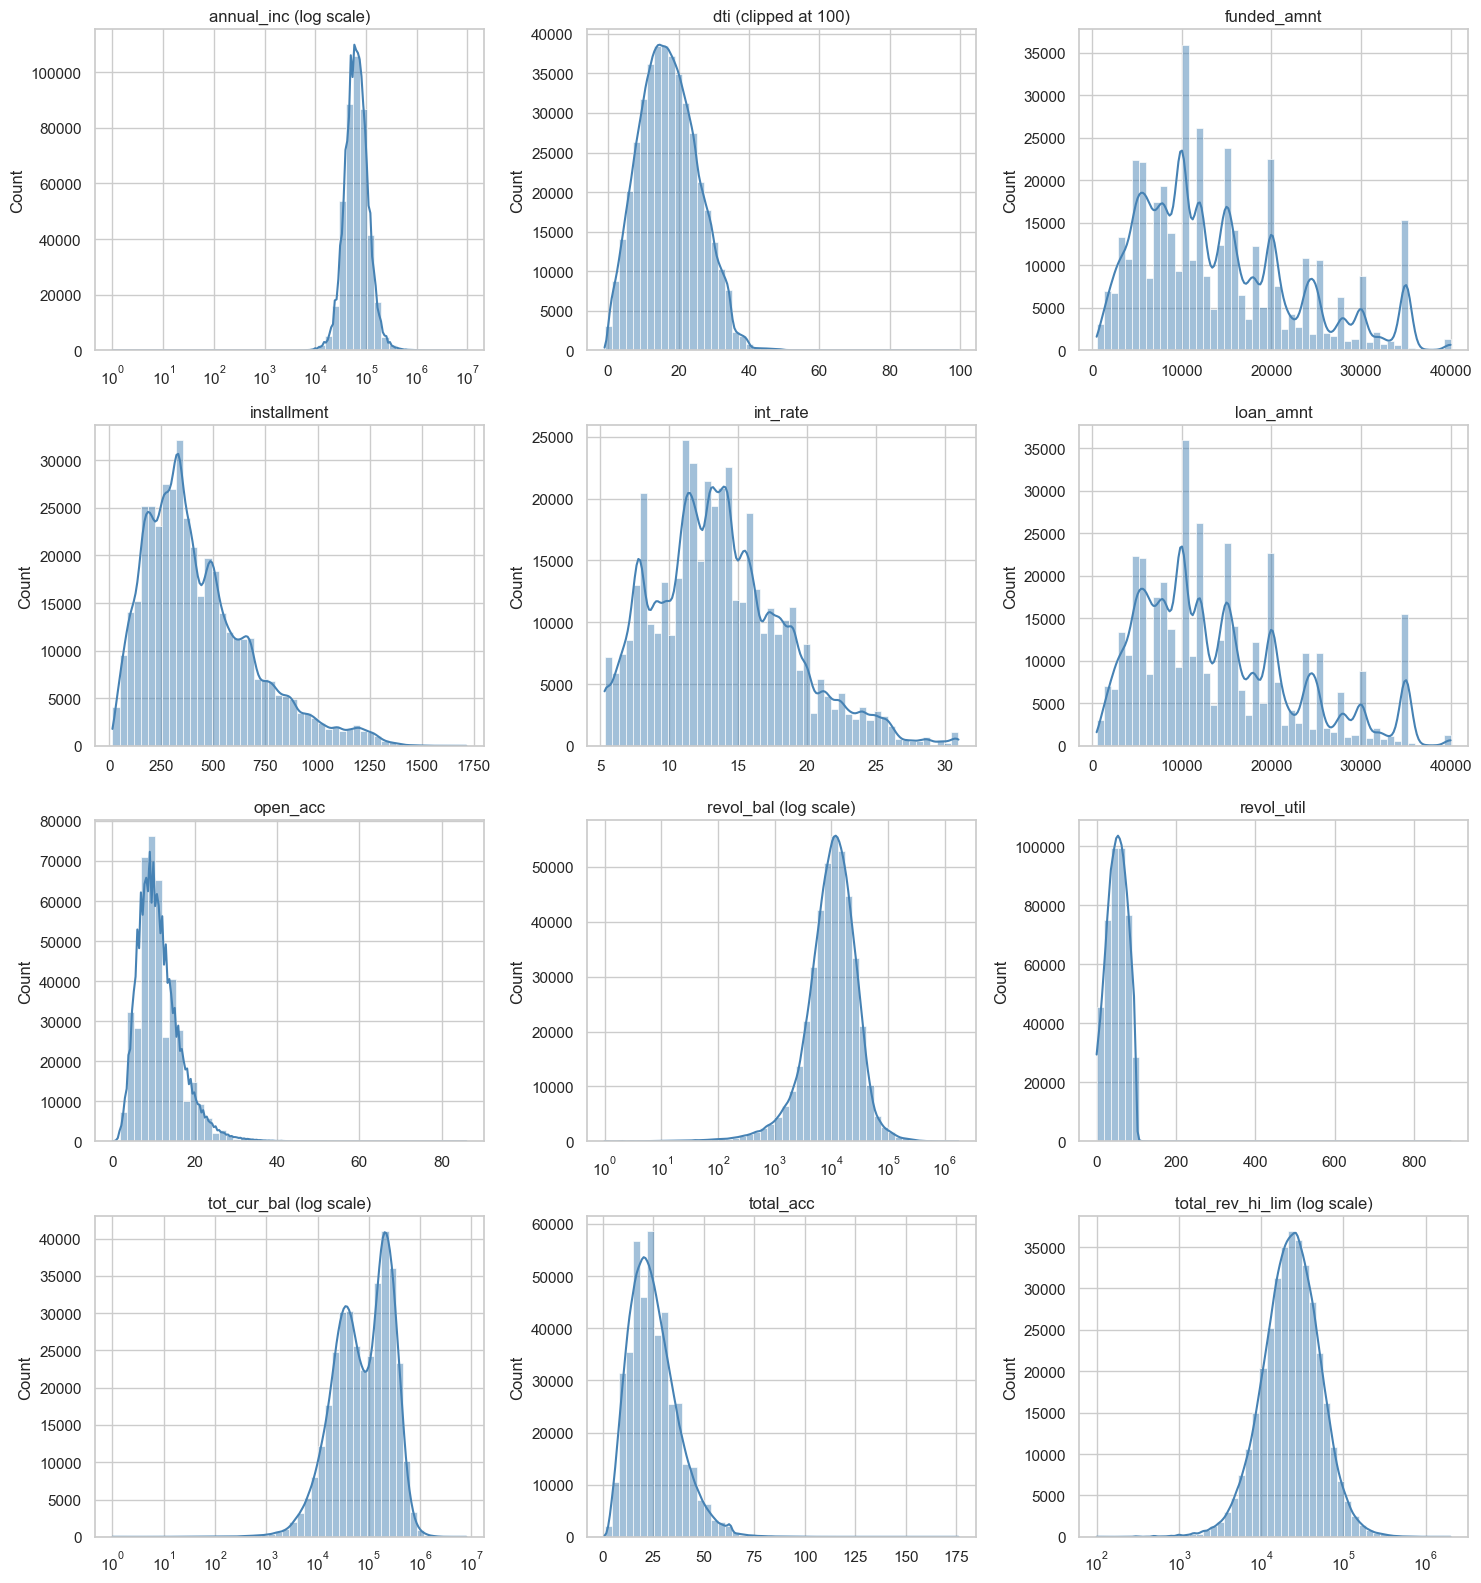

In [173]:
# Numeric columns that aren't informative as histograms:
#  - zero-inflated counts/amounts (a single spike at 0 dominates the chart)
#  - high-missing "months since" fields
#  - issue_year (a time key used for the split, not a borrower feature)
exclude_from_viz = [
    'acc_now_delinq', 'collections_12_mths_ex_med',
    'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'tot_coll_amt',
    'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record',
    'issue_year',
]
numeric_features = [c for c in usable_numeric if c not in exclude_from_viz]
print(f"Visualising {len(numeric_features)} features "
      f"(excluding zero-inflated, high-missing, and time-key columns)")

# Transformations
# log scale: heavily right-skewed continuous money features
log_scale_features = [
    'annual_inc',         # income from $4k to $9.5M
    'revol_bal',          # revolving balance, mostly $1k-$30k with long tail
    'tot_cur_bal',        # total current balance across all accounts
    'total_rev_hi_lim',   # total revolving credit limit
]
# clip: extreme values are likely data errors, not real
clip_features = {
    'dti': 100,           # DTI above 100% is unrealistic for healthy borrowers
}

# Grid setup
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Plot each feature with the appropriate transformation
for i, col in enumerate(numeric_features):
    data = df[col].dropna()

    if col in log_scale_features:
        data = data[data > 0]                       # log needs strictly positive values
        sns.histplot(data, bins=50, ax=axes[i], color='steelblue', kde=True, log_scale=True)
        axes[i].set_title(f"{col} (log scale)")
    elif col in clip_features:
        data = data[data <= clip_features[col]]
        sns.histplot(data, bins=50, ax=axes[i], color='steelblue', kde=True)
        axes[i].set_title(f"{col} (clipped at {clip_features[col]})")
    else:
        sns.histplot(data, bins=50, ax=axes[i], color='steelblue', kde=True)
        axes[i].set_title(col)

    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


**Key observations (selected highlights):**

- **`loan_amnt` and `funded_amnt` are near-identical**, both spiking at round numbers ($10k, $15k, $20k, $35k). The two columns are effectively duplicates, so one can be dropped for logistic regression.

- **`int_rate` is multi-modal** — the clusters reflect LendingClub's grade-based pricing tiers rather than a smooth continuum.

- **`annual_inc` and `revol_bal` are roughly log-normal** (bell-shaped on the log axis), confirming the log transform was the right choice for these.

- **`tot_cur_bal` and `total_rev_hi_lim` each show a sharp central spike** — this is the median-imputation that applied to their ~15% missing values, not a real cluster. Harmless for XGBoost (tree splits ignore it), but worth remembering before using these in logistic regression.

- **`dti` peaks around 15–20** and tails off past 40, consistent with LendingClub screening out very high-DTI applicants.


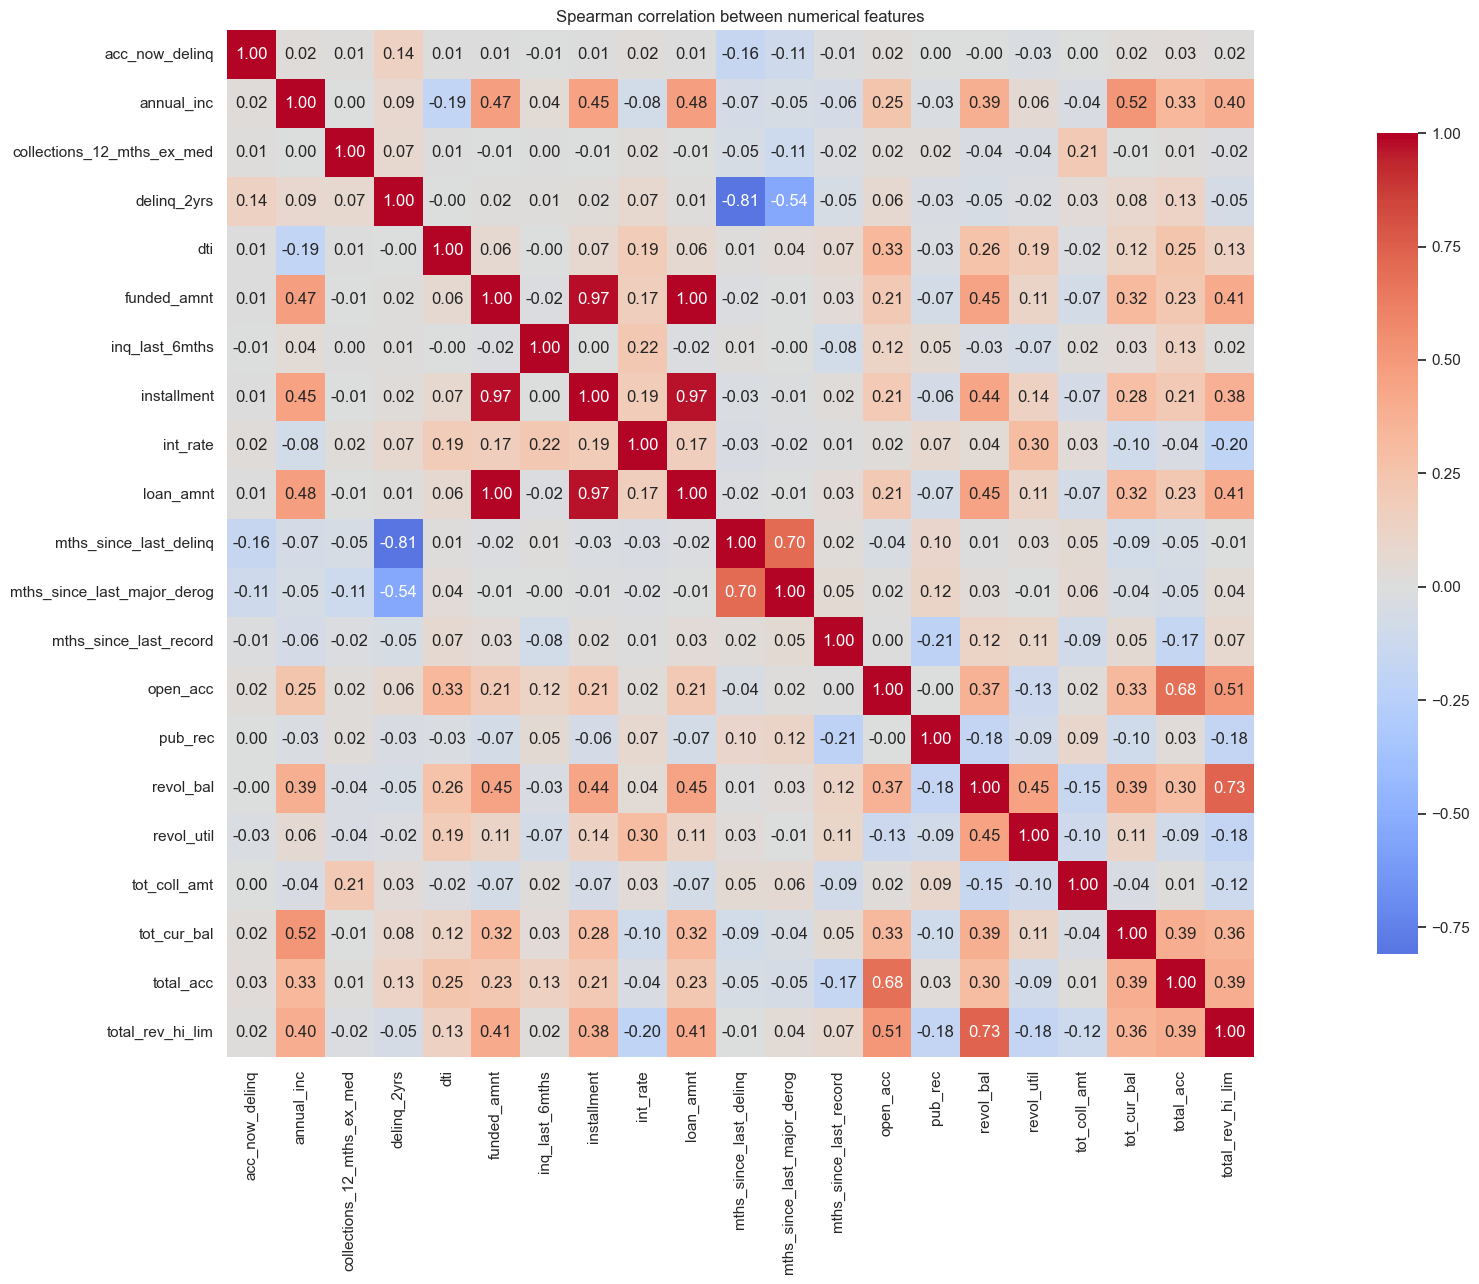

In [174]:
# Correlation heatmap (Spearman is selected because robust to outliers in skewed financial data)
corr = df[usable_numeric].corr(method='spearman')   # use the full numeric feature set, not the trimmed histogram set

plt.figure(figsize=(25, 13))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Spearman correlation between numerical features')
plt.tight_layout()
plt.show()

**Key correlations:**

- **`loan_amnt` = `funded_amnt` (1.00), and both ≈ `installment` (0.97)** — these three are effectively the same information. Keep one (`loan_amnt`) for logistic regression; XGBoost can keep all.

- **`pub_rec` <-> `mths_since_last_record` (−0.98)** — almost perfectly redundant: they both encode the same public-record event. Worth a quick check, but one can be dropped.

- **`delinq_2yrs` <-> `mths_since_last_delinq` (−0.70)** and **`mths_since_last_delinq` ↔ `mths_since_last_major_derog` (0.50)** — the delinquency/derogatory fields overlap, as expected.

- **`open_acc` <-> `total_acc` (0.68)** and **`revol_bal` <-> `total_rev_hi_lim` (0.66)** — moderate; related but not duplicates.

- **The adverse-signal counts** (`acc_now_delinq`, `collections_12_mths_ex_med`, `tot_coll_amt`, `inq_last_6mths`) correlate near-zero with everything — each adds independent risk information.

**Implication:** XGBoost is unaffected by correlated features. For the logistic-regression baseline, drop the redundant ones (keep `loan_amnt`, drop `funded_amnt`/`installment`; keep one of `pub_rec` / `mths_since_last_record`).


## 3. Data Preparation


### 3.1 Data cleaning

**Note on annual_inc outliers:** During EDA extreme values are identified
in `annual_inc` (max $9.5M, 99th percentile $250k). However, these values are chosen not to cap 
or filter during cleaning because:

- XGBoost (primary model) handles outliers robustly without preprocessing
- For the logistic regression baseline, log-transformation of `annual_inc` 
  in Feature Engineering part naturally compresses the long tail


In [175]:
# Capture the pre-cleaning default rate as a baseline for the 3.1.4 sanity
# check. Must be computed BEFORE any row filtering (column drops don't change it).
default_rate_before_cleaning = df['target'].mean()
print(f"Default rate before cleaning: {default_rate_before_cleaning:.2%}")

Default rate before cleaning: 19.88%


#### 3.1.1 Drop columns flagged in EDA

In [176]:
# Compile all columns to drop, based on EDA categorisation
# (These lists were defined in Section 2.2.5)

columns_to_drop = (
    drop_post_origination +     # would leak the target
    drop_identifiers +          # not features
    drop_joint +                # >99% missing
    drop_newer_bureau +         # ~60% missing
    drop_text +                 # high-cardinality text
    drop_constant +             # near-constant
    drop_other                  # target source, split key, dup, EDA helpers
)

# Defensive filter to keep only columns actually present
columns_to_drop = [c for c in columns_to_drop if c in df.columns]

# Record the dataset state before dropping variables to make sure nothing unexpected happens.
shape_before = df.shape

# Apply the drop
df = df.drop(columns=columns_to_drop)

print(f"Shape before drop: {shape_before}")
print(f"Shape after drop:  {df.shape}")
print(f"Dropped {len(columns_to_drop)} columns; {df.shape[1]} columns remain.")

Shape before drop: (424890, 75)
Shape after drop:  (424890, 35)
Dropped 40 columns; 35 columns remain.


#### 3.1.2 Handle missing values

Three different missing-value treatments are applied based on the patterns identified in EDA:

| Treatment | Columns | Justification | Citation |
|---|---|---|---|
| Sentinel fill (999) | `mths_since_last_delinq`, `mths_since_last_record`, `mths_since_last_major_derog` | Missingness is structural (event never occurred) and carries only a weak signal (~1-2pp), so it is encoded as a sentinel value | Amit, H. (2025). "XGBoost in R: A Practical Guide." Medium. |
| Median imputation | `tot_cur_bal`, `total_rev_hi_lim`, `tot_coll_amt` | The missing values come from differences in loan timing, not borrower behaviour, so they are not likely to improve prediction. |
| Treat missing as own category ('unknown') | `emp_length` | Missingness itself predicts +9pp higher default rate (28.5% vs 19.4%). Recommended when missingness is non-random and carries information  | Bhuva, L. (2025). "Handling Missing Values in Categorical Data." Medium |

In [177]:
# Sentinel fill: 999 means 'no such event ever occurred'.
# These columns are structurally missing when the borrower has never had a delinquency or public record. 
# Missing values are replaced with number like 999 to preserve this "no event" meaning for the model.
for col in keep_sentinel_fill:
    if col in df.columns:
        df[col] = df[col].fillna(999)

print("Sentinel fill (999) applied to:")
for col in keep_sentinel_fill:
    if col in df.columns:
        remaining_missing = df[col].isnull().sum()
        print(f"  {col:<35} remaining missing: {remaining_missing}")

Sentinel fill (999) applied to:
  mths_since_last_delinq              remaining missing: 0
  mths_since_last_record              remaining missing: 0
  mths_since_last_major_derog         remaining missing: 0


In [178]:
# Median imputation: 
for col in keep_median_impute:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  {col:<35} imputed with median = {median_val:,.0f}")

  tot_cur_bal                         imputed with median = 85,934
  total_rev_hi_lim                    imputed with median = 23,600
  tot_coll_amt                        imputed with median = 0


In [179]:
# Treat emp_length missing as "unknown" since missingness itself is signal
# (+9pp default rate when missing, per Section 2.2.5 finding)
if 'emp_length' in df.columns:
    n_missing_before = df['emp_length'].isnull().sum()
    df['emp_length'] = df['emp_length'].fillna('unknown')
    print(f"emp_length: filled {n_missing_before:,} missing values with 'unknown'")

emp_length: filled 20,752 missing values with 'unknown'


#### 3.1.3 Filter implausible values

EDA identified a small number of rows with DTI values above 100%, which is implausible for a healthy applicant and almost certainly data errors, so these rows are removed. A handful of rows with residual missing values in otherwise-kept features are also dropped here (<0.1% per column).

In [180]:
# Filter DTI outliers (>100% is implausible for healthy borrowers)
rows_before = len(df)
df = df[df['dti'] <= 100].copy()
rows_after = len(df)

print(f"Rows before DTI filter: {rows_before:,}")
print(f"Rows after DTI filter:  {rows_after:,}")
print(f"Removed: {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before:.2%})")

Rows before DTI filter: 424,890
Rows after DTI filter:  424,798
Removed: 92 (0.02%)


In [181]:
# Drop rows with residual missing values
# After applying the main treatment plan above, ~400 rows remain with missing values in features not covered by sentinel/median/category treatment.
# Since the count is very small (<0.1% per column), these rows are dropped rather than impute. 
# This produces a fully clean dataset for both XGBoost (which handles NaN natively) and logistic regression (which doesn't).
rows_before = len(df)
df = df.dropna()
rows_after = len(df)
print(f"Dropped {rows_before - rows_after:,} rows with residual missing values")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dropped 471 rows with residual missing values
Final shape: 424,327 rows × 35 columns


#### 3.1.4 Cleaned dataset summary

Verify the cleaned dataset is ready for the next stage:
- Reasonable shape (rows and columns)
- No unexpected missing values in features we kept
- Default rate hasn't shifted materially from the EDA stage

In [182]:
# Reset index after row filtering to avoid gaps
df = df.reset_index(drop=True)

print("CLEANED DATASET SUMMARY")
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Default rate sanity check - compares against pre-cleaning rate captured earlier
default_rate_after_cleaning = df['target'].mean()

print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nDefault rate before cleaning: {default_rate_before_cleaning:.2%}")
print(f"Default rate after cleaning:  {default_rate_after_cleaning:.2%}")


# Confirm no unexpected missingness in features
print(f"\nRemaining missingness:")
remaining_missing = df.isnull().sum().sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) > 0:
    print(remaining_missing)
else:
    print("  No missing values remain.")

CLEANED DATASET SUMMARY

Shape: 424,327 rows × 35 columns

Target distribution:
target
0    339985
1     84342
Name: count, dtype: int64

Default rate before cleaning: 19.88%
Default rate after cleaning:  19.88%

Remaining missingness:
  No missing values remain.
